# ORIGIN

The Yelp reviews dataset consists of reviews from Yelp. It is extracted from the Yelp Dataset Challenge 2015 data. For more information, please refer to http://www.yelp.com/dataset_challenge

The Yelp reviews polarity dataset is constructed by Xiang Zhang (xiang.zhang@nyu.edu) from the above dataset. It is first used as a text classification benchmark in the following paper: Xiang Zhang, Junbo Zhao, Yann LeCun. Character-level Convolutional Networks for Text Classification. Advances in Neural Information Processing Systems 28 (NIPS 2015).


# DESCRIPTION

The Yelp reviews polarity dataset is constructed by considering stars 1 and 2 negative, and 3 and 4 positive. For each polarity 280,000 training samples and 19,000 testing samples are take randomly. In total there are 560,000 trainig samples and 38,000 testing samples. Negative polarity is class 1, and positive class 2.

### Link to the dataset: https://www.kaggle.com/datasets/yacharki/yelp-reviews-for-sentianalysis-binary-np-csv

## 1. Ucitavanje i pregled podataka

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud
import re

In [2]:
train_df = pd.read_csv(
    "data/train.csv",
    sep=",",
    quotechar='"',
    doublequote=True
)

test_df = pd.read_csv(
    "data/test.csv",
    sep=",",
    quotechar='"',
    doublequote=True
)


In [3]:
train_df.shape

(560000, 2)

In [4]:
test_df.shape

(38000, 2)

In [5]:
train_df.head()

,class_index,review_text
0,1,"Unfortunately, the frustration of being Dr. Go..."
1,2,Been going to Dr. Goldberg for over 10 years. ...
2,1,I don't know what Dr. Goldberg was like before...
3,1,I'm writing this review to give you a heads up...
4,2,All the food is great here. But the best thing...


In [6]:
train_df["review_text"][4]

'All the food is great here. But the best thing they have is their wings. Their wings are simply fantastic!!  The \\"Wet Cajun\\" are by the best & most popular.  I also like the seasoned salt wings.  Wing Night is Monday & Wednesday night, $0.75 whole wings!\\n\\nThe dining area is nice. Very family friendly! The bar is very nice is well.  This place is truly a Yinzer\'s dream!!  \\"Pittsburgh Dad\\" would love this place n\'at!!'

In [7]:
train_df["review_text"][2]

"I don't know what Dr. Goldberg was like before  moving to Arizona, but let me tell you, STAY AWAY from this doctor and this office. I was going to Dr. Johnson before he left and Goldberg took over when Johnson left. He is not a caring doctor. He is only interested in the co-pay and having you come in for medication refills every month. He will not give refills and could less about patients's financial situations. Trying to get your 90 days mail away pharmacy prescriptions through this guy is a joke. And to make matters even worse, his office staff is incompetent. 90% of the time when you call the office, they'll put you through to a voice mail, that NO ONE ever answers or returns your call. Both my adult children and husband have decided to leave this practice after experiencing such frustration. The entire office has an attitude like they are doing you a favor. Give me a break! Stay away from this doc and the practice. You deserve better and they will not be there when you really nee

## 2. Priprema podataka

### Ciscenje teksta

In [8]:
def clean_text(text):
    """Ciscenje teksta za NLP analizu sentimenta."""
    # Popravka escape karaktera iz CSV formata
    text = text.replace('\\"', '"')
    text = text.replace("\\'", "'")
    text = text.replace("\\n", " ")

    # Prebacivanje u mala slova
    text = text.lower()

    # Uklanjanje HTML tagova
    text = re.sub(r'<.*?>', '', text)

    # Uklanjanje URL-ova
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # Uklanjanje specijalnih karaktera i brojeva (zadrzavamo samo slova i razmake)
    text = re.sub(r'[^a-z\s]', '', text)

    # Uklanjanje visestrukih razmaka
    text = re.sub(r'\s+', ' ', text)

    return text.strip()


train_df["review_text"] = train_df["review_text"].apply(clean_text)
test_df["review_text"] = test_df["review_text"].apply(clean_text)

print("Ciscenje zavrseno!")
print(f"Primer ociscene recenzije:\n{train_df['review_text'][4]}")

Ciscenje zavrseno!
Primer ociscene recenzije:
all the food is great here but the best thing they have is their wings their wings are simply fantastic the wet cajun are by the best most popular i also like the seasoned salt wings wing night is monday wednesday night whole wings the dining area is nice very family friendly the bar is very nice is well this place is truly a yinzers dream pittsburgh dad would love this place nat


In [9]:
train_df["review_text"][4]

'all the food is great here but the best thing they have is their wings their wings are simply fantastic the wet cajun are by the best most popular i also like the seasoned salt wings wing night is monday wednesday night whole wings the dining area is nice very family friendly the bar is very nice is well this place is truly a yinzers dream pittsburgh dad would love this place nat'

In [10]:
train_df["review_text"][2]

'i dont know what dr goldberg was like before moving to arizona but let me tell you stay away from this doctor and this office i was going to dr johnson before he left and goldberg took over when johnson left he is not a caring doctor he is only interested in the copay and having you come in for medication refills every month he will not give refills and could less about patientss financial situations trying to get your days mail away pharmacy prescriptions through this guy is a joke and to make matters even worse his office staff is incompetent of the time when you call the office theyll put you through to a voice mail that no one ever answers or returns your call both my adult children and husband have decided to leave this practice after experiencing such frustration the entire office has an attitude like they are doing you a favor give me a break stay away from this doc and the practice you deserve better and they will not be there when you really need them i have never felt compel

### Mapiranje klasa

In [11]:
train_df["class_index"] = train_df["class_index"].astype(int).map({1: 0, 2: 1})
test_df["class_index"] = test_df["class_index"].astype(int).map({1: 0, 2: 1})

In [12]:
train_df["class_index"].unique()

array([0, 1])

### Provera kvaliteta podataka

In [13]:
print("Null values in train_df:")
print(train_df.isna().sum())

Null values in train_df:
class_index    0
review_text    0
dtype: int64


In [14]:
print("Null values in test_df:")
print(test_df.isna().sum())

Null values in test_df:
class_index    0
review_text    0
dtype: int64


In [15]:
print("Checking duplicates")
print(f"Training set: {train_df.duplicated().sum()}")
print(f"Test set: {test_df.duplicated().sum()}")

Checking duplicates
Training set: 412
Test set: 2


### Ciscenje dupliakata

In [16]:
train_df = train_df.drop_duplicates(keep="first")
test_df = test_df.drop_duplicates(keep="first")

## 3. Exploratory Data Analysis (EDA)

### Distribucija klasa

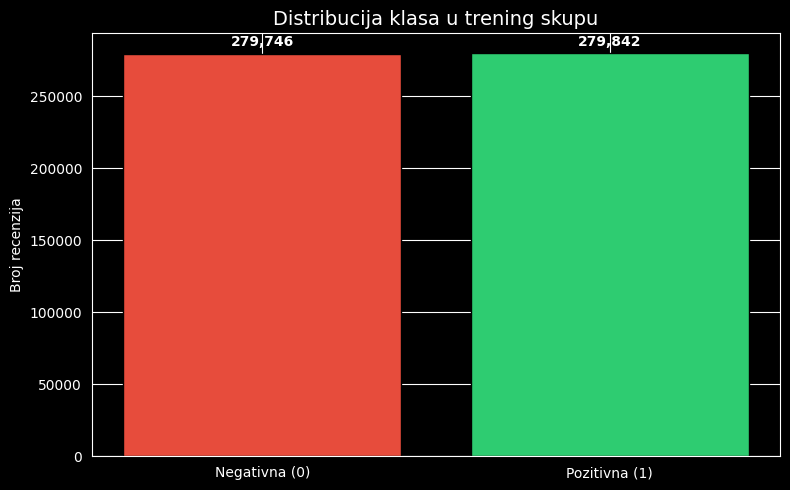

Negativne: 279,746 (50.0%)
Pozitivne: 279,842 (50.0%)


In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
class_counts = train_df["class_index"].value_counts().sort_index()
bars = ax.bar(["Negativna (0)", "Pozitivna (1)"], class_counts.values, color=["#e74c3c", "#2ecc71"], edgecolor="black")
ax.set_title("Distribucija klasa u trening skupu", fontsize=14)
ax.set_ylabel("Broj recenzija")
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 5000, f"{v:,}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Negativne: {class_counts[0]:,} ({class_counts[0]/len(train_df)*100:.1f}%)")
print(f"Pozitivne: {class_counts[1]:,} ({class_counts[1]/len(train_df)*100:.1f}%)")

### Distribucija duzine recenzija (broj reci)

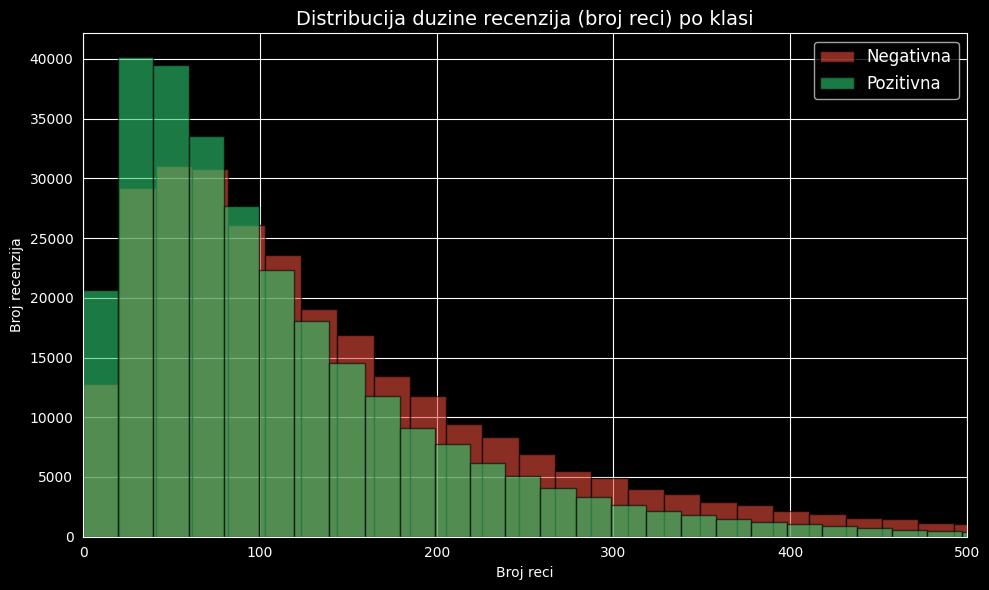

Prosecna duzina recenzije: 132.3 reci
Medijana duzine recenzije: 96.0 reci
95. percentil duzine: 370 reci


In [18]:
train_df["word_count"] = train_df["review_text"].str.split().str.len()
test_df["word_count"] = test_df["review_text"].str.split().str.len()

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(train_df[train_df["class_index"] == 0]["word_count"], bins=50, alpha=0.6,
        label="Negativna", color="#e74c3c", edgecolor="black")
ax.hist(train_df[train_df["class_index"] == 1]["word_count"], bins=50, alpha=0.6,
        label="Pozitivna", color="#2ecc71", edgecolor="black")
ax.set_title("Distribucija duzine recenzija (broj reci) po klasi", fontsize=14)
ax.set_xlabel("Broj reci")
ax.set_ylabel("Broj recenzija")
ax.legend(fontsize=12)
ax.set_xlim(0, 500)
plt.tight_layout()
plt.show()

print(f"Prosecna duzina recenzije: {train_df['word_count'].mean():.1f} reci")
print(f"Medijana duzine recenzije: {train_df['word_count'].median():.1f} reci")
print(f"95. percentil duzine: {train_df['word_count'].quantile(0.95):.0f} reci")

### Najcesce reci - Top 30 ukupno

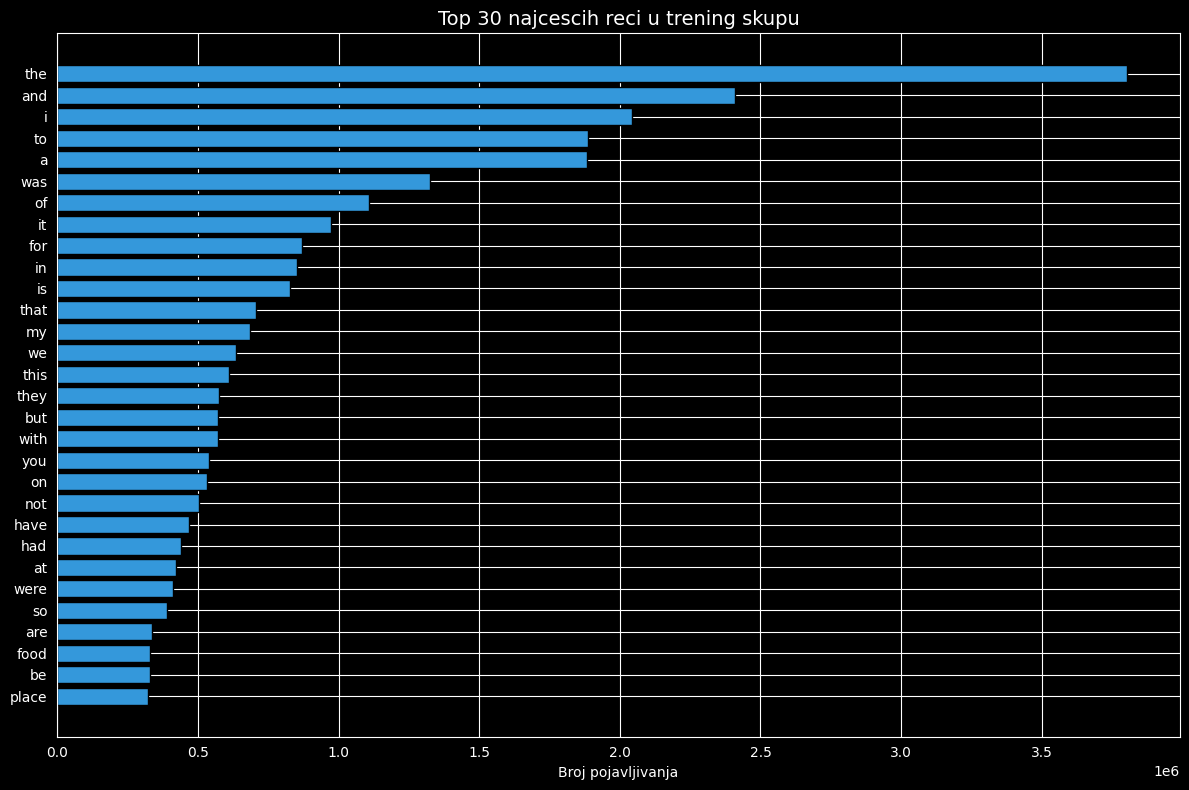

In [19]:
all_words = " ".join(train_df["review_text"]).split()
word_counts = Counter(all_words)
top_30 = word_counts.most_common(30)

fig, ax = plt.subplots(figsize=(12, 8))
words = [w[0] for w in top_30][::-1]
counts = [w[1] for w in top_30][::-1]
ax.barh(words, counts, color="#3498db", edgecolor="black")
ax.set_title("Top 30 najcescih reci u trening skupu", fontsize=14)
ax.set_xlabel("Broj pojavljivanja")
plt.tight_layout()
plt.show()

### Najcesce reci - Top 20 po klasi

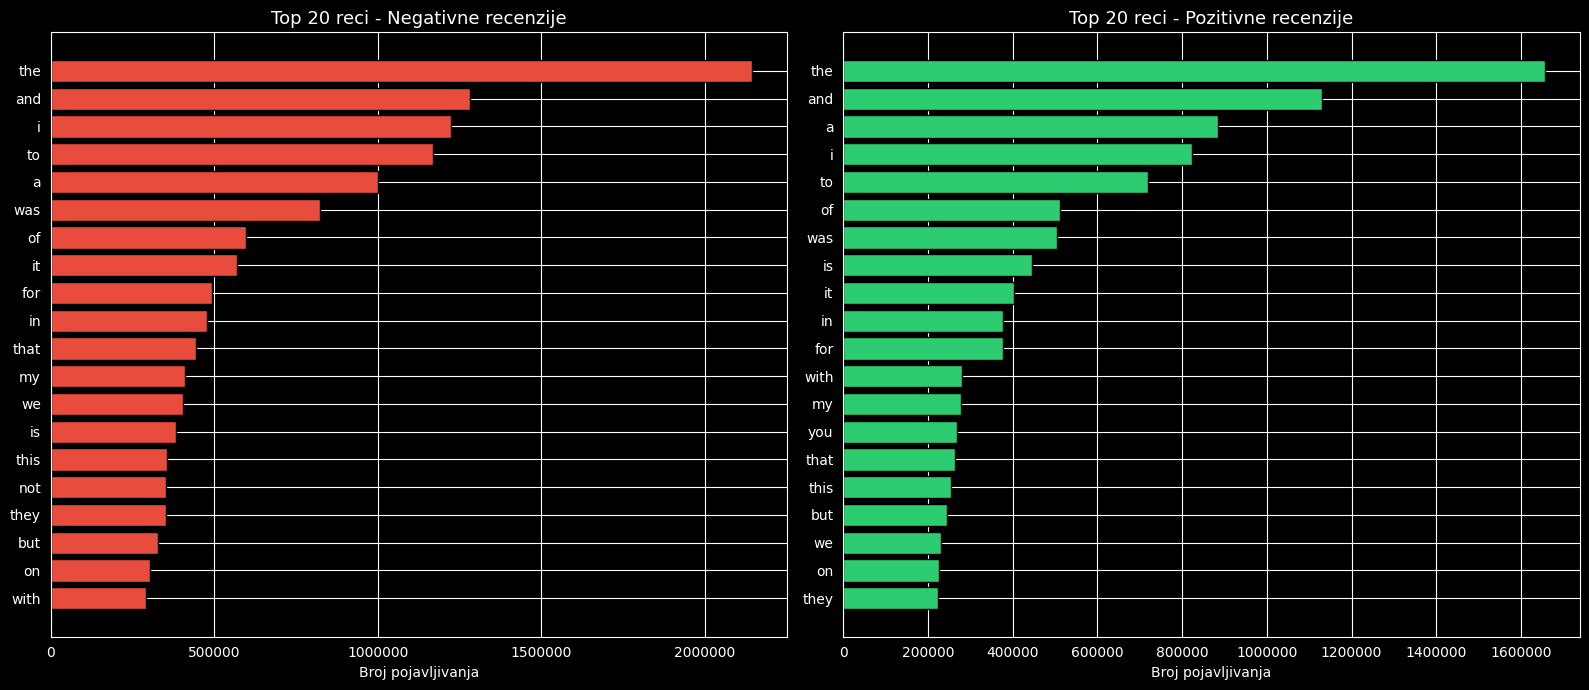

In [20]:
neg_words = " ".join(train_df[train_df["class_index"] == 0]["review_text"]).split()
pos_words = " ".join(train_df[train_df["class_index"] == 1]["review_text"]).split()

neg_counts = Counter(neg_words).most_common(20)
pos_counts = Counter(pos_words).most_common(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh([w[0] for w in neg_counts][::-1], [w[1] for w in neg_counts][::-1], color="#e74c3c", edgecolor="black")
axes[0].set_title("Top 20 reci - Negativne recenzije", fontsize=13)
axes[0].ticklabel_format(style='plain', useOffset=False, axis='x')
axes[0].set_xlabel("Broj pojavljivanja")

axes[1].barh([w[0] for w in pos_counts][::-1], [w[1] for w in pos_counts][::-1], color="#2ecc71", edgecolor="black")
axes[1].set_title("Top 20 reci - Pozitivne recenzije", fontsize=13)
axes[1].ticklabel_format(style='plain', useOffset=False, axis='x')
axes[1].set_xlabel("Broj pojavljivanja")

plt.tight_layout()
plt.show()

### Word Cloud - Negativne vs Pozitivne recenzije

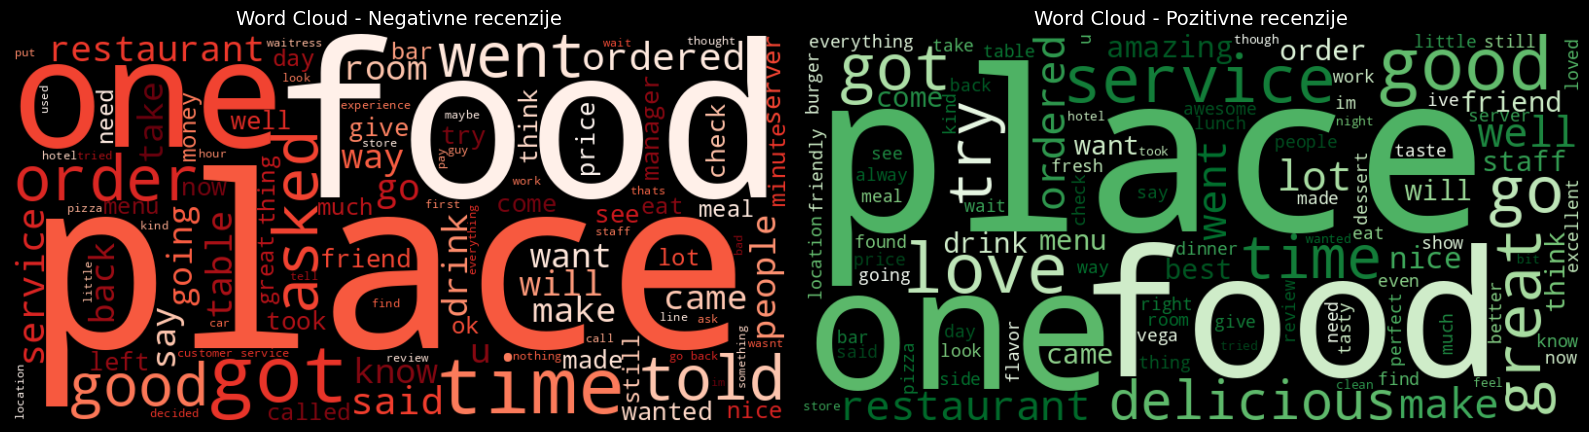

In [21]:
neg_text = " ".join(train_df[train_df["class_index"] == 0]["review_text"])
pos_text = " ".join(train_df[train_df["class_index"] == 1]["review_text"])

wc_neg = WordCloud(width=800, height=400, background_color="black",
                   colormap="Reds", max_words=100, random_state=42).generate(neg_text)
wc_pos = WordCloud(width=800, height=400, background_color="black",
                   colormap="Greens", max_words=100, random_state=42).generate(pos_text)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(wc_neg, interpolation="bilinear")
axes[0].set_title("Word Cloud - Negativne recenzije", fontsize=14)
axes[0].axis("off")

axes[1].imshow(wc_pos, interpolation="bilinear")
axes[1].set_title("Word Cloud - Pozitivne recenzije", fontsize=14)
axes[1].axis("off")

plt.tight_layout()
plt.show()

### Box plot duzine teksta po klasama

/tmp/ipykernel_83688/1900681527.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=["Negativna (0)", "Pozitivna (1)"],


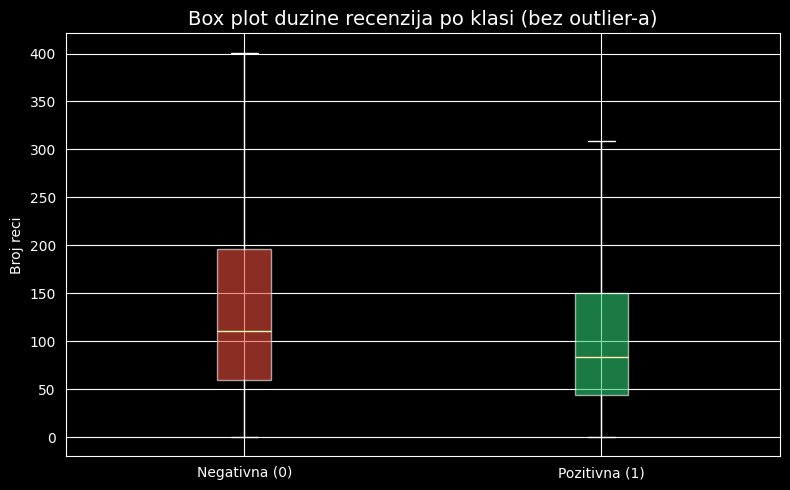

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
data_to_plot = [
    train_df[train_df["class_index"] == 0]["word_count"],
    train_df[train_df["class_index"] == 1]["word_count"]
]
bp = ax.boxplot(data_to_plot, labels=["Negativna (0)", "Pozitivna (1)"],
                patch_artist=True, showfliers=False)
bp["boxes"][0].set_facecolor("#e74c3c")
bp["boxes"][0].set_alpha(0.6)
bp["boxes"][1].set_facecolor("#2ecc71")
bp["boxes"][1].set_alpha(0.6)
ax.set_title("Box plot duzine recenzija po klasi (bez outlier-a)", fontsize=14)
ax.set_ylabel("Broj reci")
plt.tight_layout()
plt.show()

### Prosecne statistike po klasi

In [23]:
train_df["char_count"] = train_df["review_text"].str.len()

stats = train_df.groupby("class_index").agg(
    prosecni_broj_reci=("word_count", "mean"),
    medijana_broj_reci=("word_count", "median"),
    prosecni_broj_karaktera=("char_count", "mean"),
    medijana_broj_karaktera=("char_count", "median"),
    min_broj_reci=("word_count", "min"),
    max_broj_reci=("word_count", "max"),
).round(2)

stats.index = ["Negativna (0)", "Pozitivna (1)"]
print("Statistike duzine teksta po klasi:")
stats

Statistike duzine teksta po klasi:


,prosecni_broj_reci,medijana_broj_reci,prosecni_broj_karaktera,medijana_broj_karaktera,min_broj_reci,max_broj_reci
Negativna (0),150.45,111.0,779.22,574.0,0,1027
Pozitivna (1),114.12,84.0,599.89,439.0,0,995


## 4. Tokenizacija i priprema podataka za neuronsku mrezu

Neuronske mreze ne mogu direktno da rade sa tekstom - potrebno je tekst pretvoriti u numericke vrednosti.
Ovaj proces se sastoji iz sledecih koraka:

### 1. Tokenizacija
**Sta radi:** Razbija tekst na pojedinacne reci (tokene).

**Zasto:** Neuronska mreza ne razume recenice kao celinu. Moramo razbiti tekst na najmanje smislene jedinice (reci)
da bismo svaku rec mogli da predstavimo brojem.

**Primer:** `"the food is great"` -> `["the", "food", "is", "great"]`

Koristimo jednostavan `split()` posto smo tekst vec ocistili (samo mala slova i razmaci).

### 2. Izgradnja vokabulara
**Sta radi:** Kreira recnik koji svakoj reci dodeljuje jedinstven broj (indeks).

**Zasto:** Neuronska mreza radi sa brojevima, ne sa stringovima. Vokabular je mapa `rec -> broj`.

**Primer:** `{"the": 2, "food": 3, "is": 4, "great": 5, ...}`

Koristimo samo **top 10,000 najcescih reci** iz trening seta jer:
- Retke reci se pojavljuju mozda samo 1-2 puta i mreza ne moze da nauci njihovo znacenje
- Smanjuje dimenzionalnost i ubrzava treniranje
- Top 10,000 reci pokriva ~97% svih pojavljivanja reci u tekstu

Vokabular gradimo rucno pomocu `Counter` klase iz Python standardne biblioteke.

### 3. Specijalni tokeni
- **`<PAD>` (index 0):** Koristi se za dopunjavanje kracih sekvenci do iste duzine (padding).
  Neuronska mreza zahteva da svi inputi u jednom batch-u budu iste duzine.
- **`<UNK>` (index 1):** Zamenjuje reci koje nisu u vokabularu (nepoznate reci).
  Ako se u test setu pojavi rec koja nije bila u trening setu, koristimo `<UNK>` umesto nje.

### 4. Padding i Truncation
**Sta radi:** Sve sekvence svodi na istu duzinu (`MAX_LEN`).

**Zasto:** PyTorch tensor mora imati fiksne dimenzije. Ako su recenzije razlicite duzine
(neke imaju 10 reci, neke 500), moramo ih svesti na istu duzinu.

- **Truncation:** Sekvence duze od `MAX_LEN` se skracuju (odsecaju se visak reci sa kraja)
- **Padding:** Sekvence krace od `MAX_LEN` se dopunjavaju nulama (`<PAD>` tokenom) do pune duzine

`MAX_LEN` biramo na osnovu distribucije duzina iz EDA-e (95. percentil = ~370 tokena).

In [24]:
all_words = " ".join(train_df["review_text"]).split()
word_freq = Counter(all_words)
total_words = len(all_words)

for size in [10000, 15000, 25000, 50000]:
  top_words = set(w for w, _ in word_freq.most_common(size))
  covered = sum(c for w, c in word_freq.items() if w in top_words)
  print(f"Top {size:,}: pokriva {covered/total_words*100:.2f}% teksta")


Top 10,000: pokriva 96.94% teksta
Top 15,000: pokriva 97.89% teksta
Top 25,000: pokriva 98.67% teksta
Top 50,000: pokriva 99.25% teksta


In [25]:
# Hiperparametri za tokenizaciju
VOCAB_SIZE = 10_000
MAX_LEN = 370

# 1. Tokenizacija - koristimo jednostavan split() posto je tekst vec ociscen (samo mala slova i razmaci)
def tokenize(text):
    return text.split()

# Primer tokenizacije
sample = "the food is great i love this place"
print(f"Original: {sample}")
print(f"Tokeni:   {tokenize(sample)}")

Original: the food is great i love this place
Tokeni:   ['the', 'food', 'is', 'great', 'i', 'love', 'this', 'place']


In [27]:
# 2. Rucna izgradnja vokabulara iz trening seta
all_words = " ".join(train_df["review_text"]).split()
word_freq = Counter(all_words)

# Specijalni tokeni
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"
PAD_IDX = 0
UNK_IDX = 1

# Uzimamo top VOCAB_SIZE - 2 najcescih reci (minus 2 za PAD i UNK)
most_common = word_freq.most_common(VOCAB_SIZE - 2)

# Kreiranje recnika: rec -> indeks
word2idx = {PAD_TOKEN: PAD_IDX, UNK_TOKEN: UNK_IDX}
for idx, (word, _) in enumerate(most_common, start=2):
    word2idx[word] = idx

# Obrnuti recnik: indeks -> rec (korisno za debugovanje)
idx2word = {idx: word for word, idx in word2idx.items()}

print(f"Velicina vokabulara: {len(word2idx)}")
print(f"Indeks za '{PAD_TOKEN}': {word2idx[PAD_TOKEN]}")
print(f"Indeks za '{UNK_TOKEN}': {word2idx[UNK_TOKEN]}")
print(f"Indeks za 'great': {word2idx.get('great', UNK_IDX)}")
print(f"Indeks za 'terrible': {word2idx.get('terrible', UNK_IDX)}")
print(f"Indeks za nepoznatu rec 'xyzabc': {word2idx.get('xyzabc', UNK_IDX)}")

Velicina vokabulara: 10000
Indeks za '<PAD>': 0
Indeks za '<UNK>': 1
Indeks za 'great': 51
Indeks za 'terrible': 449
Indeks za nepoznatu rec 'xyzabc': 1


In [28]:
# 3. Funkcija za pretvaranje teksta u numericku sekvencu sa padding/truncation
def text_to_indices(text, word2idx, max_len):
    tokens = tokenize(text)
    # Svaku rec zameni njenim indeksom, nepoznate reci dobijaju UNK_IDX
    indices = [word2idx.get(token, UNK_IDX) for token in tokens]

    # Truncation: odseci ako je duze od max_len
    if len(indices) > max_len:
        indices = indices[:max_len]
    # Padding: dopuni nulama (PAD_IDX) ako je krace od max_len
    else:
        indices = indices + [PAD_IDX] * (max_len - len(indices))

    return indices


# Primer
sample_text = train_df["review_text"].iloc[0]
sample_indices = text_to_indices(sample_text, word2idx, MAX_LEN)
print(f"Tekst (prvih 100 char): {sample_text[:100]}...")
print(f"Indeksi (prvih 20): {sample_indices[:20]}")
print(f"Duzina sekvence: {len(sample_indices)}")
print(f"Dekodiran nazad: {' '.join(idx2word[i] for i in sample_indices[:20])}")

Tekst (prvih 100 char): unfortunately the frustration of being dr goldbergs patient is a repeat of the experience ive had wi...
Indeksi (prvih 20): [630, 2, 4123, 8, 167, 906, 1, 1585, 12, 6, 2043, 8, 2, 134, 103, 24, 19, 27, 183, 81]
Duzina sekvence: 370
Dekodiran nazad: unfortunately the frustration of being dr <UNK> patient is a repeat of the experience ive had with so many other


## 5. Train/Validation Split

In [29]:
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_df["review_text"].values,
    train_df["class_index"].values,
    test_size=0.20,
    random_state=42,
    stratify=train_df["class_index"].values
)

test_texts = test_df["review_text"].values
test_labels = test_df["class_index"].values

print(f"Trening set:     {len(train_texts):,} uzoraka")
print(f"Validacioni set: {len(val_texts):,} uzoraka")
print(f"Test set:        {len(test_texts):,} uzoraka")
print(f"\nDistribucija klasa u trening setu:   {np.mean(train_labels):.3f} (udeo pozitivnih)")
print(f"Distribucija klasa u validacionom setu: {np.mean(val_labels):.3f} (udeo pozitivnih)")

Trening set:     447,670 uzoraka
Validacioni set: 111,918 uzoraka
Test set:        37,998 uzoraka

Distribucija klasa u trening setu:   0.500 (udeo pozitivnih)
Distribucija klasa u validacionom setu: 0.500 (udeo pozitivnih)


## 6. PyTorch Dataset i DataLoader

In [30]:
import torch
from torch.utils.data import Dataset, DataLoader

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, word2idx, max_len):
        self.texts = texts
        self.labels = labels
        self.word2idx = word2idx
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        indices = text_to_indices(text, self.word2idx, self.max_len)
        return torch.tensor(indices, dtype=torch.long), torch.tensor(label, dtype=torch.float)


BATCH_SIZE = 128

train_dataset = SentimentDataset(train_texts, train_labels, word2idx, MAX_LEN)
val_dataset = SentimentDataset(val_texts, val_labels, word2idx, MAX_LEN)
test_dataset = SentimentDataset(test_texts, test_labels, word2idx, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Broj batch-eva - train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}")

# Provera jednog batch-a
sample_x, sample_y = next(iter(train_loader))
print(f"Oblik batch-a (X): {sample_x.shape}")
print(f"Oblik batch-a (y): {sample_y.shape}")

Broj batch-eva - train: 3498, val: 875, test: 297
Oblik batch-a (X): torch.Size([128, 370])
Oblik batch-a (y): torch.Size([128])


## 7. Definicija modela

### Model A: MLP (Feedforward Neural Network) - Baseline

Najjednostavnija arhitektura. Embedding sloj pretvara svaku rec u vektor,
zatim se radi prosek svih vektora u sekvenci (Global Average Pooling),
i na kraju potpuno povezani slojevi klasifikuju sentiment.

```
Input -> Embedding -> GlobalAvgPool -> FC(128,128) -> ReLU -> Dropout -> FC(128,1)
```

In [31]:
import torch.nn as nn

class SentimentMLP(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x: (batch_size, seq_len)
        embedded = self.embedding(x)          # (batch_size, seq_len, embed_dim)
        pooled = embedded.mean(dim=1)          # (batch_size, embed_dim) - prosek svih embeddings-a
        out = self.dropout(self.relu(self.fc1(pooled)))
        out = self.fc2(out)                    # (batch_size, 1)
        return out.squeeze(1)

### Model B: BiLSTM (Bidirectional Long Short-Term Memory)

LSTM cita sekvencu rec po rec i pamti kontekst. Bidirekcioni LSTM cita i unapred i unazad,
pa hvata kontekst iz oba smera. Koristimo poslednje skriveno stanje za klasifikaciju.

```
Input -> Embedding -> BiLSTM(2 sloja) -> Dropout -> FC(256,1)
```

In [32]:
class SentimentBiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=0.3 if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim * 2, 1)  # *2 jer je bidirekcioni

    def forward(self, x):
        # x: (batch_size, seq_len)
        embedded = self.embedding(x)                    # (batch_size, seq_len, embed_dim)
        lstm_out, (hidden, cell) = self.lstm(embedded)
        # Spajamo poslednji hidden state iz forward i backward smera
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)  # (batch_size, hidden_dim*2)
        hidden = self.dropout(hidden)
        out = self.fc(hidden)                            # (batch_size, 1)
        return out.squeeze(1)

### Model C: TextCNN (Convolutional Neural Network za tekst)

Koristi 1D konvolucije sa razlicitim velicinama kernela (3, 4, 5) koje hvataju n-grame
razlicitih duzina. Svaki kernel hvata lokalne obrasce (npr. "not good", "very bad").
Rezultati se spajaju i prolaze kroz potpuno povezan sloj.

```
Input -> Embedding -> Conv1d(kernel=3) -|
                   -> Conv1d(kernel=4) -|-> Concat -> Dropout -> FC(300,1)
                   -> Conv1d(kernel=5) -|
```

In [33]:
class SentimentCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_filters, filter_sizes, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, fs) for fs in filter_sizes
        ])
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(num_filters * len(filter_sizes), 1)

    def forward(self, x):
        # x: (batch_size, seq_len)
        embedded = self.embedding(x)               # (batch_size, seq_len, embed_dim)
        embedded = embedded.permute(0, 2, 1)       # (batch_size, embed_dim, seq_len) za Conv1d

        conv_outputs = []
        for conv in self.convs:
            c = torch.relu(conv(embedded))          # (batch_size, num_filters, seq_len-fs+1)
            c = c.max(dim=2)[0]                     # Global Max Pool -> (batch_size, num_filters)
            conv_outputs.append(c)

        cat = torch.cat(conv_outputs, dim=1)        # (batch_size, num_filters * len(filter_sizes))
        cat = self.dropout(cat)
        out = self.fc(cat)                          # (batch_size, 1)
        return out.squeeze(1)

### Model D: Hibridni CNN + BiLSTM

CNN izvlaci lokalne obrasce (n-grame), a zatim BiLSTM cita te obrasce sekvencijalno
i hvata dugacke zavisnosti izmedju njih.

```
Input -> Embedding -> Conv1d(3,4,5) -> ReLU -> Concat -> BiLSTM -> Dropout -> FC(256,1)
```

In [34]:
class SentimentCNNLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_filters, filter_sizes, hidden_dim, num_layers, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, fs) for fs in filter_sizes
        ])
        self.lstm = nn.LSTM(
            num_filters * len(filter_sizes), hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=0.3 if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        # x: (batch_size, seq_len)
        embedded = self.embedding(x)           # (batch, seq_len, embed_dim)
        embedded = embedded.permute(0, 2, 1)   # (batch, embed_dim, seq_len)

        # CNN izvlaci lokalne feature-e
        conv_outputs = []
        for conv in self.convs:
            c = torch.relu(conv(embedded))     # (batch, num_filters, seq_len - fs + 1)
            conv_outputs.append(c)

        # Svi outputi se trimuju na najkracu duzinu pa konkateniraju
        min_len = min(c.size(2) for c in conv_outputs)
        conv_outputs = [c[:, :, :min_len] for c in conv_outputs]
        cat = torch.cat(conv_outputs, dim=1)   # (batch, num_filters*3, min_len)
        cat = cat.permute(0, 2, 1)             # (batch, min_len, num_filters*3)

        # LSTM cita CNN feature-e sekvencijalno
        lstm_out, (hidden, cell) = self.lstm(cat)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)  # (batch, hidden_dim*2)
        hidden = self.dropout(hidden)
        out = self.fc(hidden)                  # (batch, 1)
        return out.squeeze(1)

## 8. Treniranje modela

In [35]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch_x, batch_y in loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer.zero_grad()
        output = model(batch_x)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_x.size(0)
        predictions = (torch.sigmoid(output) >= 0.5).float()
        correct += (predictions == batch_y).sum().item()
        total += batch_x.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            output = model(batch_x)
            loss = criterion(output, batch_y)

            total_loss += loss.item() * batch_x.size(0)
            predictions = (torch.sigmoid(output) >= 0.5).float()
            correct += (predictions == batch_y).sum().item()
            total += batch_x.size(0)

    return total_loss / total, correct / total


def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                device, num_epochs=10, patience=3, model_name="model"):
    best_val_loss = float("inf")
    patience_counter = 0
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), f"models/{model_name}_best.pt")
            print(f"  -> Sacuvan najbolji model (val_loss: {val_loss:.4f})")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  -> Early stopping na epohi {epoch+1}")
                break

    # Ucitaj najbolji sacuvani model
    model.load_state_dict(torch.load(f"models/{model_name}_best.pt", weights_only=True))
    return model, history

In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Uredjaj: {device}")

# Hiperparametri
EMBED_DIM = 128
HIDDEN_DIM = 128
NUM_LAYERS = 2
NUM_FILTERS = 100
FILTER_SIZES = [3, 4, 5]
NUM_EPOCHS = 10
PATIENCE = 3
LEARNING_RATE = 0.001

criterion = nn.BCEWithLogitsLoss()

Uredjaj: cuda


### Treniranje Model A: MLP

In [37]:
model_mlp = SentimentMLP(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, PAD_IDX).to(device)
optimizer_mlp = torch.optim.Adam(model_mlp.parameters(), lr=LEARNING_RATE)
scheduler_mlp = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_mlp, mode="min", patience=1, factor=0.5)

print(f"Broj parametara: {sum(p.numel() for p in model_mlp.parameters()):,}")
print(model_mlp)
print("\n" + "="*70)
model_mlp, history_mlp = train_model(
    model_mlp, train_loader, val_loader, criterion, optimizer_mlp, scheduler_mlp,
    device, num_epochs=NUM_EPOCHS, patience=PATIENCE, model_name="mlp"
)

Broj parametara: 1,296,641
SentimentMLP(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (fc1): Linear(in_features=128, out_features=128, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)

Epoch 1/10 | Train Loss: 0.2289 | Train Acc: 0.9064 | Val Loss: 0.1751 | Val Acc: 0.9299
  -> Sacuvan najbolji model (val_loss: 0.1751)
Epoch 2/10 | Train Loss: 0.1676 | Train Acc: 0.9343 | Val Loss: 0.1706 | Val Acc: 0.9325
  -> Sacuvan najbolji model (val_loss: 0.1706)
Epoch 3/10 | Train Loss: 0.1614 | Train Acc: 0.9367 | Val Loss: 0.1715 | Val Acc: 0.9319
Epoch 4/10 | Train Loss: 0.1582 | Train Acc: 0.9378 | Val Loss: 0.1719 | Val Acc: 0.9319
Epoch 5/10 | Train Loss: 0.1524 | Train Acc: 0.9404 | Val Loss: 0.1689 | Val Acc: 0.9322
  -> Sacuvan najbolji model (val_loss: 0.1689)
Epoch 6/10 | Train Loss: 0.1509 | Train Acc: 0.9405 | Val Loss: 0.1690 | Val Acc: 0.9327
Epoch 7/10 | Train Loss: 0.1494 | Train Acc: 0.

### Treniranje Model B: BiLSTM

In [38]:
model_lstm = SentimentBiLSTM(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, PAD_IDX).to(device)
optimizer_lstm = torch.optim.Adam(model_lstm.parameters(), lr=LEARNING_RATE)
scheduler_lstm = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_lstm, mode="min", patience=1, factor=0.5)

print(f"Broj parametara: {sum(p.numel() for p in model_lstm.parameters()):,}")
print(model_lstm)
print("\n" + "="*70)
model_lstm, history_lstm = train_model(
    model_lstm, train_loader, val_loader, criterion, optimizer_lstm, scheduler_lstm,
    device, num_epochs=NUM_EPOCHS, patience=PATIENCE, model_name="bilstm"
)

Broj parametara: 1,939,713
SentimentBiLSTM(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)

Epoch 1/10 | Train Loss: 0.2394 | Train Acc: 0.8972 | Val Loss: 0.1350 | Val Acc: 0.9467
  -> Sacuvan najbolji model (val_loss: 0.1350)
Epoch 2/10 | Train Loss: 0.1218 | Train Acc: 0.9539 | Val Loss: 0.1174 | Val Acc: 0.9542
  -> Sacuvan najbolji model (val_loss: 0.1174)
Epoch 3/10 | Train Loss: 0.0989 | Train Acc: 0.9629 | Val Loss: 0.1129 | Val Acc: 0.9567
  -> Sacuvan najbolji model (val_loss: 0.1129)
Epoch 4/10 | Train Loss: 0.0805 | Train Acc: 0.9703 | Val Loss: 0.1196 | Val Acc: 0.9570
Epoch 5/10 | Train Loss: 0.0633 | Train Acc: 0.9771 | Val Loss: 0.1324 | Val Acc: 0.9567
Epoch 6/10 | Train Loss: 0.0384 | Train Acc: 0.9869 | Val Loss: 0.1461 | Val Acc: 0.9566
  -> Early stopping na epohi 6


### Treniranje Model C: TextCNN

In [39]:
model_cnn = SentimentCNN(VOCAB_SIZE, EMBED_DIM, NUM_FILTERS, FILTER_SIZES, PAD_IDX).to(device)
optimizer_cnn = torch.optim.Adam(model_cnn.parameters(), lr=LEARNING_RATE)
scheduler_cnn = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_cnn, mode="min", patience=1, factor=0.5)

print(f"Broj parametara: {sum(p.numel() for p in model_cnn.parameters()):,}")
print(model_cnn)
print("\n" + "="*70)
model_cnn, history_cnn = train_model(
    model_cnn, train_loader, val_loader, criterion, optimizer_cnn, scheduler_cnn,
    device, num_epochs=NUM_EPOCHS, patience=PATIENCE, model_name="textcnn"
)

Broj parametara: 1,434,201
SentimentCNN(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(128, 100, kernel_size=(3,), stride=(1,))
    (1): Conv1d(128, 100, kernel_size=(4,), stride=(1,))
    (2): Conv1d(128, 100, kernel_size=(5,), stride=(1,))
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=300, out_features=1, bias=True)
)

Epoch 1/10 | Train Loss: 0.2556 | Train Acc: 0.8900 | Val Loss: 0.1578 | Val Acc: 0.9374
  -> Sacuvan najbolji model (val_loss: 0.1578)
Epoch 2/10 | Train Loss: 0.1668 | Train Acc: 0.9348 | Val Loss: 0.1603 | Val Acc: 0.9370
Epoch 3/10 | Train Loss: 0.1459 | Train Acc: 0.9439 | Val Loss: 0.1394 | Val Acc: 0.9466
  -> Sacuvan najbolji model (val_loss: 0.1394)
Epoch 4/10 | Train Loss: 0.1332 | Train Acc: 0.9494 | Val Loss: 0.1370 | Val Acc: 0.9477
  -> Sacuvan najbolji model (val_loss: 0.1370)
Epoch 5/10 | Train Loss: 0.1231 | Train Acc: 0.9539 | Val Loss: 0.1366 | Val Acc: 0.9483
  -> Sacuvan najbo

### Treniranje Model D: CNN+BiLSTM

In [40]:
model_hybrid = SentimentCNNLSTM(
    VOCAB_SIZE, EMBED_DIM, NUM_FILTERS, FILTER_SIZES, HIDDEN_DIM, NUM_LAYERS, PAD_IDX
).to(device)
optimizer_hybrid = torch.optim.Adam(model_hybrid.parameters(), lr=LEARNING_RATE)
scheduler_hybrid = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_hybrid, mode="min", patience=1, factor=0.5)

print(f"Broj parametara: {sum(p.numel() for p in model_hybrid.parameters()):,}")
print(model_hybrid)
print("\n" + "="*70)
model_hybrid, history_hybrid = train_model(
    model_hybrid, train_loader, val_loader, criterion, optimizer_hybrid, scheduler_hybrid,
    device, num_epochs=NUM_EPOCHS, patience=PATIENCE, model_name="cnn_bilstm"
)

Broj parametara: 2,269,741
SentimentCNNLSTM(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(128, 100, kernel_size=(3,), stride=(1,))
    (1): Conv1d(128, 100, kernel_size=(4,), stride=(1,))
    (2): Conv1d(128, 100, kernel_size=(5,), stride=(1,))
  )
  (lstm): LSTM(300, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)

Epoch 1/10 | Train Loss: 0.2466 | Train Acc: 0.8942 | Val Loss: 0.1630 | Val Acc: 0.9364
  -> Sacuvan najbolji model (val_loss: 0.1630)
Epoch 2/10 | Train Loss: 0.1481 | Train Acc: 0.9423 | Val Loss: 0.1430 | Val Acc: 0.9448
  -> Sacuvan najbolji model (val_loss: 0.1430)
Epoch 3/10 | Train Loss: 0.1280 | Train Acc: 0.9509 | Val Loss: 0.1292 | Val Acc: 0.9494
  -> Sacuvan najbolji model (val_loss: 0.1292)
Epoch 4/10 | Train Loss: 0.1116 | Train Acc: 0.9577 | Val Loss: 0.1297 | Val Acc: 0.9496
Epoch 5/10 | 

## 9. Evaluacija modela

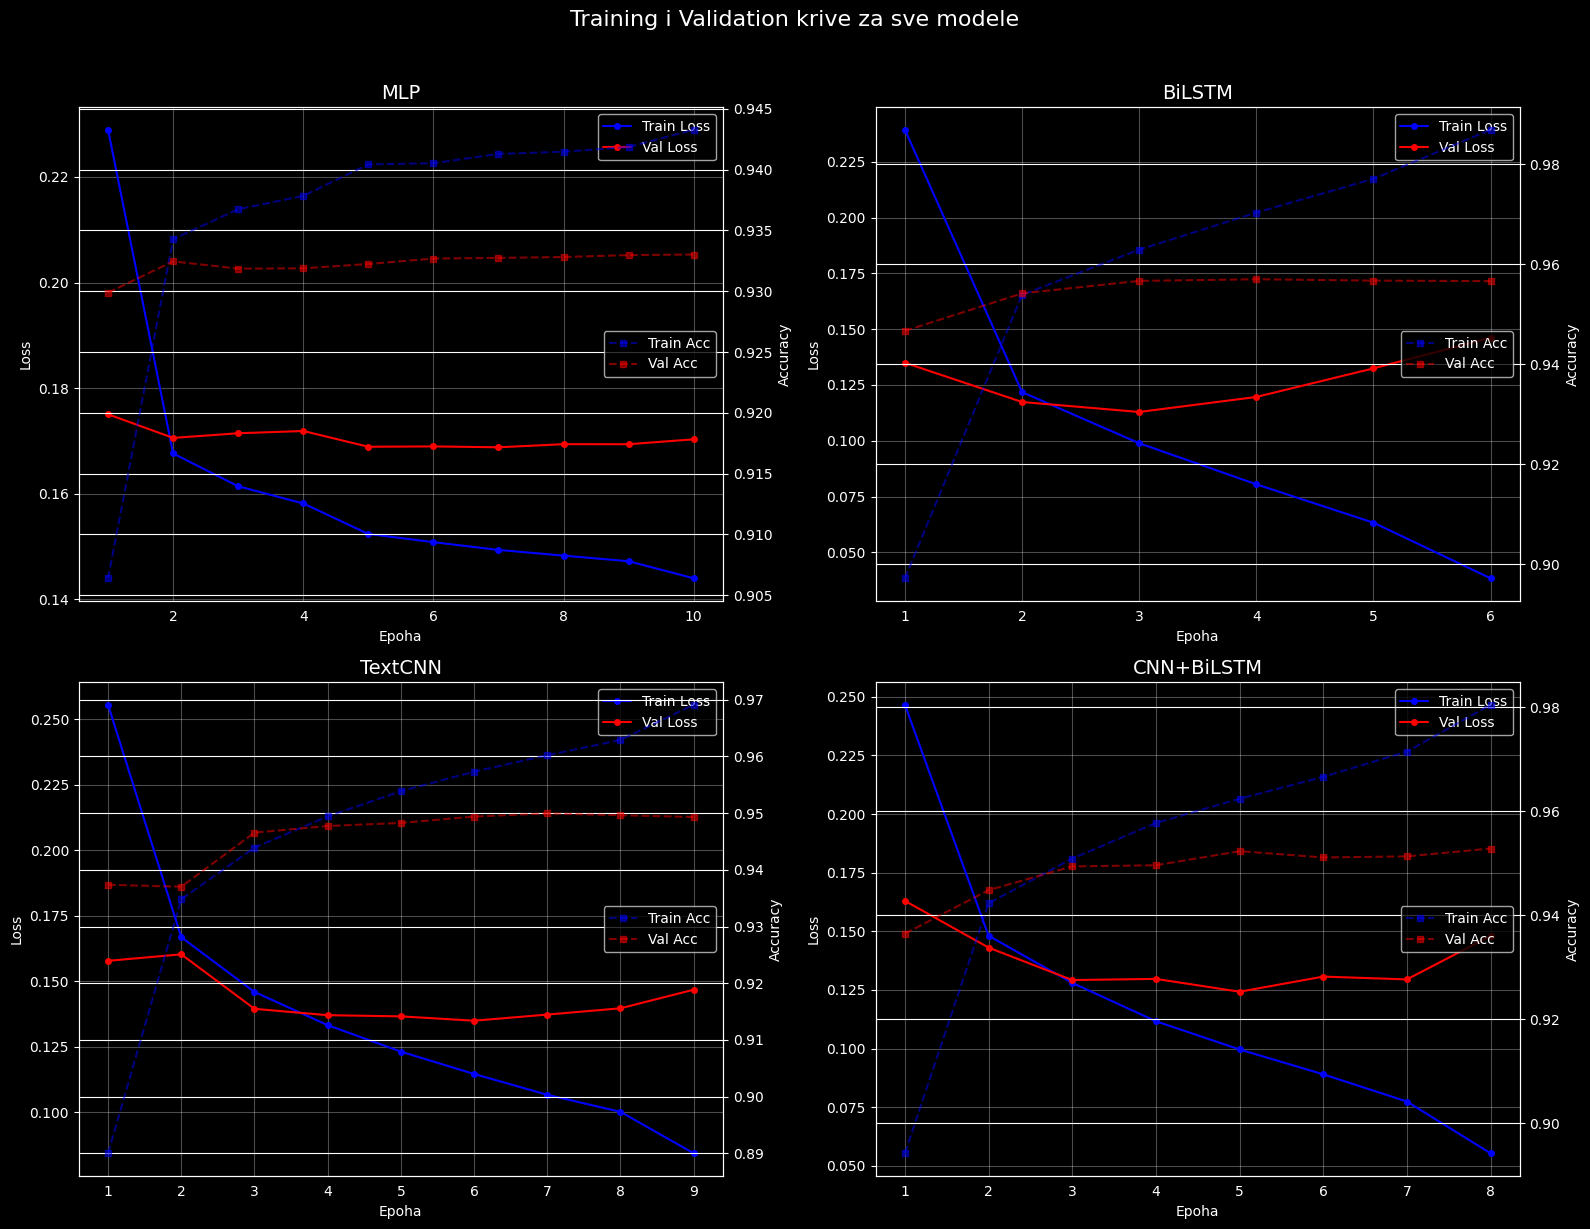

In [55]:
histories = {
    "MLP": history_mlp,
    "BiLSTM": history_lstm,
    "TextCNN": history_cnn,
    "CNN+BiLSTM": history_hybrid,
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes = axes.flatten()

for idx, (name, history) in enumerate(histories.items()):
    ax = axes[idx]
    epochs = range(1, len(history["train_loss"]) + 1)

    ax.plot(epochs, history["train_loss"], "b-o", label="Train Loss", markersize=4)
    ax.plot(epochs, history["val_loss"], "r-o", label="Val Loss", markersize=4)
    ax.set_title(f"{name}", fontsize=14)
    ax.set_xlabel("Epoha")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Dodaj accuracy na sekundarnu y-osu
    ax2 = ax.twinx()
    ax2.plot(epochs, history["train_acc"], "b--s", label="Train Acc", markersize=4, alpha=0.5)
    ax2.plot(epochs, history["val_acc"], "r--s", label="Val Acc", markersize=4, alpha=0.5)
    ax2.set_ylabel("Accuracy")
    ax2.legend(loc="center right")

plt.suptitle("Training i Validation krive za sve modele", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 10. Evaluacija modela

### Tabela metrika po modelu i diskriminatornom pragu

In [42]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_predictions(model, loader, device):
    """Vraca verovatnoce i tacne labele za ceo dataset."""
    model.eval()
    all_probs = []
    all_labels = []
    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)
            output = model(batch_x)
            probs = torch.sigmoid(output).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(batch_y.numpy())
    return np.array(all_probs), np.array(all_labels)

# Prikupi predikcije za sve modele na test setu
models_dict = {
    "MLP": model_mlp,
    "BiLSTM": model_lstm,
    "TextCNN": model_cnn,
    "CNN+BiLSTM": model_hybrid,
}

predictions = {}
for name, model in models_dict.items():
    probs, labels = get_predictions(model, test_loader, device)
    predictions[name] = {"probs": probs, "labels": labels}
    print(f"{name}: predikcije prikupljene ({len(probs)} uzoraka)")

MLP: predikcije prikupljene (37998 uzoraka)
BiLSTM: predikcije prikupljene (37998 uzoraka)
TextCNN: predikcije prikupljene (37998 uzoraka)
CNN+BiLSTM: predikcije prikupljene (37998 uzoraka)


In [43]:
# Tabela metrika za sve modele i pragove
thresholds = [0.4, 0.5, 0.6]
results = []

for name, pred in predictions.items():
    probs = pred["probs"]
    labels = pred["labels"]
    for thresh in thresholds:
        preds = (probs >= thresh).astype(int)
        results.append({
            "Model": name,
            "Prag": thresh,
            "Accuracy": accuracy_score(labels, preds),
            "Precision": precision_score(labels, preds),
            "Recall": recall_score(labels, preds),
            "F1": f1_score(labels, preds),
        })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("F1", ascending=False).reset_index(drop=True)
results_df[["Accuracy", "Precision", "Recall", "F1"]] = results_df[["Accuracy", "Precision", "Recall", "F1"]].round(4)

print("Rezultati evaluacije na test setu (sortirano po F1 score):")
results_df

Rezultati evaluacije na test setu (sortirano po F1 score):


,Model,Prag,Accuracy,Precision,Recall,F1
0,BiLSTM,0.5,0.9597,0.9600,0.9595,0.9597
1,BiLSTM,0.4,0.9591,0.9525,0.9664,0.9594
2,BiLSTM,0.6,0.9593,0.9669,0.9512,0.9590
3,CNN+BiLSTM,0.5,0.9547,0.9528,0.9568,0.9548
4,CNN+BiLSTM,0.6,0.9545,0.9621,0.9464,0.9542
5,CNN+BiLSTM,0.4,0.9530,0.9412,0.9664,0.9536
6,TextCNN,0.5,0.9525,0.9471,0.9585,0.9528
7,TextCNN,0.6,0.9516,0.9570,0.9457,0.9513
8,TextCNN,0.4,0.9493,0.9336,0.9674,0.9502
9,MLP,0.5,0.9370,0.9373,0.9367,0.9370


### Vizuelno poredjenje modela (F1 score pri pragu 0.5)

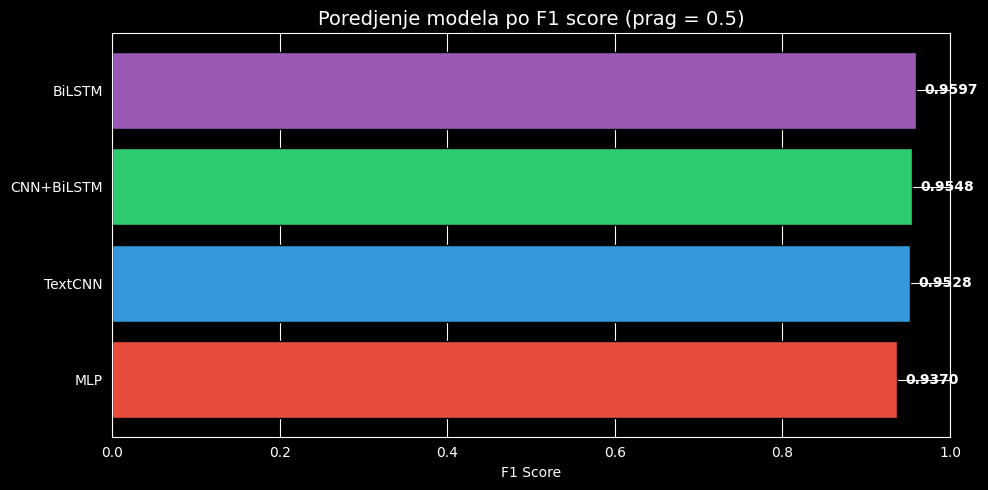

In [44]:
f1_at_05 = results_df[results_df["Prag"] == 0.5].sort_values("F1", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#e74c3c", "#3498db", "#2ecc71", "#9b59b6"]
bars = ax.barh(f1_at_05["Model"], f1_at_05["F1"], color=colors, edgecolor="black")
ax.set_xlabel("F1 Score")
ax.set_title("Poredjenje modela po F1 score (prag = 0.5)", fontsize=14)
ax.set_xlim(0, 1)

for bar, val in zip(bars, f1_at_05["F1"]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontweight="bold")

plt.tight_layout()
plt.show()

## Finalna analiza najboljeg modela

In [45]:
# Pronadji najbolji model (po F1 pri pragu 0.5)
best_row = results_df[results_df["Prag"] == 0.5].iloc[0]
best_model_name = best_row["Model"]
best_threshold = 0.5

best_probs = predictions[best_model_name]["probs"]
best_labels = predictions[best_model_name]["labels"]
best_preds = (best_probs >= best_threshold).astype(int)

print(f"Najbolji model: {best_model_name} (prag={best_threshold})")
print(f"Accuracy:  {best_row['Accuracy']:.4f}")
print(f"Precision: {best_row['Precision']:.4f}")
print(f"Recall:    {best_row['Recall']:.4f}")
print(f"F1:        {best_row['F1']:.4f}")

Najbolji model: BiLSTM (prag=0.5)
Accuracy:  0.9597
Precision: 0.9600
Recall:    0.9595
F1:        0.9597


### Confusion Matrix

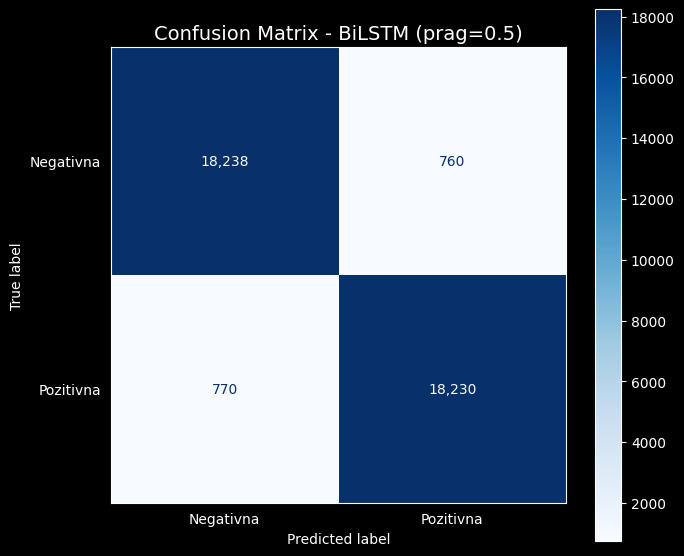

True Negatives:  18,238
False Positives: 760
False Negatives: 770
True Positives:  18,230


In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(best_labels, best_preds)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(cm, display_labels=["Negativna", "Pozitivna"])
disp.plot(ax=ax, cmap="Blues", values_format=",")
ax.grid(False)
ax.set_title(f"Confusion Matrix - {best_model_name} (prag={best_threshold})", fontsize=14)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}")
print(f"True Positives:  {tp:,}")

### ROC kriva i AUC score

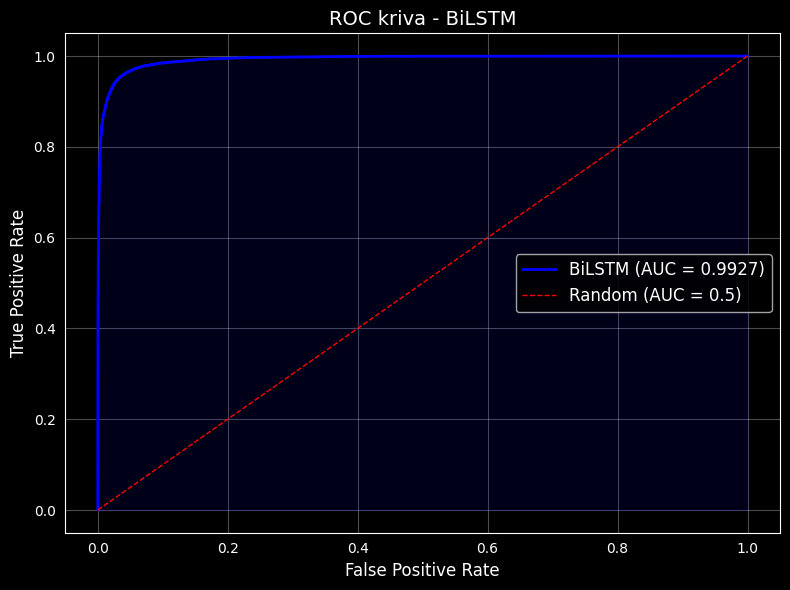

AUC Score: 0.9927


In [47]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, roc_thresholds = roc_curve(best_labels, best_probs)
auc_score = roc_auc_score(best_labels, best_probs)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, "b-", linewidth=2, label=f"{best_model_name} (AUC = {auc_score:.4f})")
ax.plot([0, 1], [0, 1], "r--", linewidth=1, label="Random (AUC = 0.5)")
ax.fill_between(fpr, tpr, alpha=0.1, color="blue")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title(f"ROC kriva - {best_model_name}", fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC Score: {auc_score:.4f}")

### Classification Report

In [48]:
from sklearn.metrics import classification_report

print(f"Classification Report - {best_model_name} (prag={best_threshold}):\n")
print(classification_report(best_labels, best_preds, target_names=["Negativna", "Pozitivna"]))

Classification Report - BiLSTM (prag=0.5):

              precision    recall  f1-score   support

   Negativna       0.96      0.96      0.96     18998
   Pozitivna       0.96      0.96      0.96     19000

    accuracy                           0.96     37998
   macro avg       0.96      0.96      0.96     37998
weighted avg       0.96      0.96      0.96     37998



### Distribucija predikcija (verovatnoca)

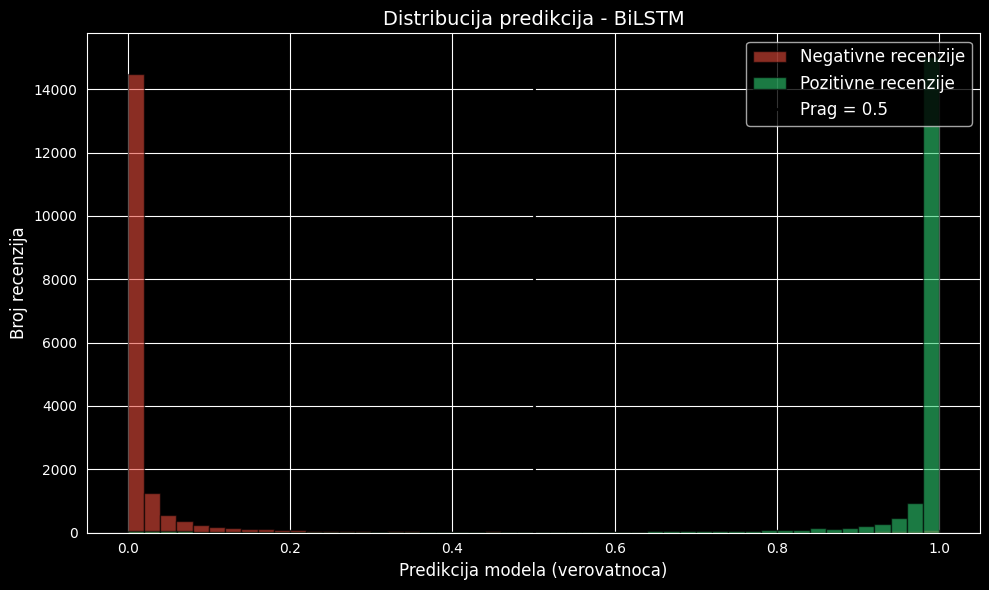

Prosecna verovatnoca za negativne: 0.0555
Prosecna verovatnoca za pozitivne: 0.9445


In [49]:
fig, ax = plt.subplots(figsize=(10, 6))

neg_probs = best_probs[best_labels == 0]
pos_probs = best_probs[best_labels == 1]

ax.hist(neg_probs, bins=50, alpha=0.6, color="#e74c3c", label="Negativne recenzije", edgecolor="black")
ax.hist(pos_probs, bins=50, alpha=0.6, color="#2ecc71", label="Pozitivne recenzije", edgecolor="black")
ax.axvline(x=best_threshold, color="black", linestyle="--", linewidth=2, label=f"Prag = {best_threshold}")
ax.set_xlabel("Predikcija modela (verovatnoca)", fontsize=12)
ax.set_ylabel("Broj recenzija", fontsize=12)
ax.set_title(f"Distribucija predikcija - {best_model_name}", fontsize=14)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

print(f"Prosecna verovatnoca za negativne: {neg_probs.mean():.4f}")
print(f"Prosecna verovatnoca za pozitivne: {pos_probs.mean():.4f}")

### Primeri predikcija (5 tacnih + 5 netacnih)

In [50]:
best_model = models_dict[best_model_name]

# Prikupi sve predikcije sa originalnim tekstovima
test_results = pd.DataFrame({
    "text": test_df["review_text"].values,
    "true_label": best_labels,
    "probability": best_probs,
    "predicted": best_preds,
    "correct": (best_preds == best_labels)
})

label_map = {0: "Negativna", 1: "Pozitivna"}

# 5 tacnih predikcija
print("=" * 80)
print("5 TACNIH PREDIKCIJA")
print("=" * 80)
correct_samples = test_results[test_results["correct"]].sample(5, random_state=42)
for i, row in correct_samples.iterrows():
    print(f"\nTacna: {label_map[row['true_label']]} | Predikcija: {label_map[row['predicted']]} | Verovatnoca: {row['probability']:.4f}")
    print(f"Tekst: {row['text'][:200]}...")
    print("-" * 80)

# 5 netacnih predikcija
print("\n" + "=" * 80)
print("5 NETACNIH PREDIKCIJA")
print("=" * 80)
incorrect_samples = test_results[~test_results["correct"]].sample(5, random_state=42)
for i, row in incorrect_samples.iterrows():
    print(f"\nTacna: {label_map[row['true_label']]} | Predikcija: {label_map[row['predicted']]} | Verovatnoca: {row['probability']:.4f}")
    print(f"Tekst: {row['text'][:200]}...")
    print("-" * 80)

5 TACNIH PREDIKCIJA

Tacna: Negativna | Predikcija: Negativna | Verovatnoca: 0.0002
Tekst: terrible service over the phone i could barely get my order out before the lady cut me off to ask me is that all the first time she did it i said let me finish the second time i said i need to speak w...
--------------------------------------------------------------------------------

Tacna: Negativna | Predikcija: Negativna | Verovatnoca: 0.0032
Tekst: cheap drinks but the bar and scene is very ghetto for being in gilbert they have a stage with old big screen tvs on it when it can be used for entertainment all the other tvs are over years old did i ...
--------------------------------------------------------------------------------

Tacna: Pozitivna | Predikcija: Pozitivna | Verovatnoca: 0.9951
Tekst: very cool there is now a mediterraneangreekmiddle eastern joint in my area even cooler they have delivery service miles out this place is in the strip mall where naga and the yogurt place is what i